This is to explore Long Short-Term Memory (LSTM) networks, a type of recurrent neural network (RNN), be use for stock price prediction.

In [3]:
#
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

#import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error

import yfinance as yf

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
#
#import yfinance as yf
#df_HSI = yf.download("^HSI", start="2022-01-01", end="2023-01-01" ).droplevel('Ticker', axis=1)

company = "AAPL"
df_HKstock = yf.download("AAPL", start="2019-01-01", end="2026-01-01",
                    auto_adjust=True ).droplevel('Ticker', axis=1)
df_HKstock

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,37.436916,37.657386,36.562155,36.718617,148158800
2019-01-03,33.707920,34.544750,33.662878,34.132260,365248800
2019-01-04,35.146893,35.215643,34.089596,34.262650,234428400
2019-01-07,35.068668,35.282027,34.587432,35.251208,219111200
2019-01-08,35.737183,35.990841,35.208534,35.455078,164101200
...,...,...,...,...,...
2025-12-24,273.066711,274.682309,271.461097,271.600701,17910600
2025-12-26,272.657867,274.622521,272.119325,273.415814,21521800
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200


In [6]:
# Save to CSV
df_HKstock.to_csv('AAPL.csv')

In [7]:
#
df_source = pd.read_csv("AAPL.csv")
df_source

,Date,Close,High,Low,Open,Volume
0,2019-01-02,37.436916,37.657386,36.562155,36.718617,148158800
1,2019-01-03,33.707920,34.544750,33.662878,34.132260,365248800
2,2019-01-04,35.146893,35.215643,34.089596,34.262650,234428400
3,2019-01-07,35.068668,35.282027,34.587432,35.251208,219111200
4,2019-01-08,35.737183,35.990841,35.208534,35.455078,164101200
...,...,...,...,...,...,...
1755,2025-12-24,273.066711,274.682309,271.461097,271.600701,17910600
1756,2025-12-26,272.657867,274.622521,272.119325,273.415814,21521800
1757,2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200
1758,2025-12-30,272.338684,273.335969,271.540868,272.069428,22139600


In [8]:
#
df_source["Date"] = pd.to_datetime(df_source["Date"], format="%Y-%m-%d")
df_source

,Date,Close,High,Low,Open,Volume
0,2019-01-02,37.436916,37.657386,36.562155,36.718617,148158800
1,2019-01-03,33.707920,34.544750,33.662878,34.132260,365248800
2,2019-01-04,35.146893,35.215643,34.089596,34.262650,234428400
3,2019-01-07,35.068668,35.282027,34.587432,35.251208,219111200
4,2019-01-08,35.737183,35.990841,35.208534,35.455078,164101200
...,...,...,...,...,...,...
1755,2025-12-24,273.066711,274.682309,271.461097,271.600701,17910600
1756,2025-12-26,272.657867,274.622521,272.119325,273.415814,21521800
1757,2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200
1758,2025-12-30,272.338684,273.335969,271.540868,272.069428,22139600


In [9]:
df_source.info()

<class 'pandas.DataFrame'>
RangeIndex: 1760 entries, 0 to 1759
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1760 non-null   datetime64[us]
 1   Close   1760 non-null   float64       
 2   High    1760 non-null   float64       
 3   Low     1760 non-null   float64       
 4   Open    1760 non-null   float64       
 5   Volume  1760 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 82.6 KB


In [10]:
df_source = df_source.set_index('Date', )     # set Date as index
df_source.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1760 entries, 2019-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1760 non-null   float64
 1   High    1760 non-null   float64
 2   Low     1760 non-null   float64
 3   Open    1760 non-null   float64
 4   Volume  1760 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 82.5 KB


In [11]:
df = df_source
df

,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,37.436916,37.657386,36.562155,36.718617,148158800
2019-01-03,33.707920,34.544750,33.662878,34.132260,365248800
2019-01-04,35.146893,35.215643,34.089596,34.262650,234428400
2019-01-07,35.068668,35.282027,34.587432,35.251208,219111200
2019-01-08,35.737183,35.990841,35.208534,35.455078,164101200
...,...,...,...,...,...
2025-12-24,273.066711,274.682309,271.461097,271.600701,17910600
2025-12-26,272.657867,274.622521,272.119325,273.415814,21521800
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200


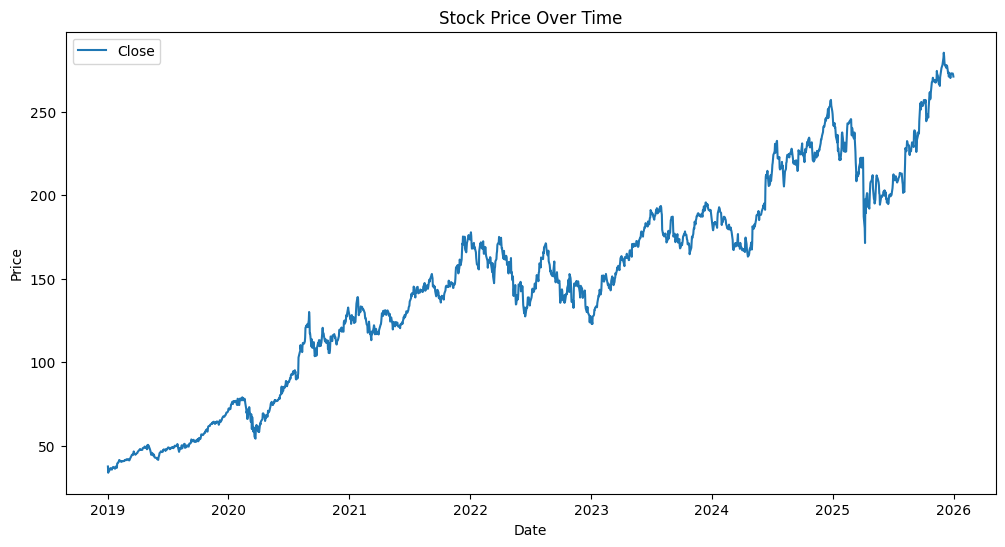

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Close')
plt.title("Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

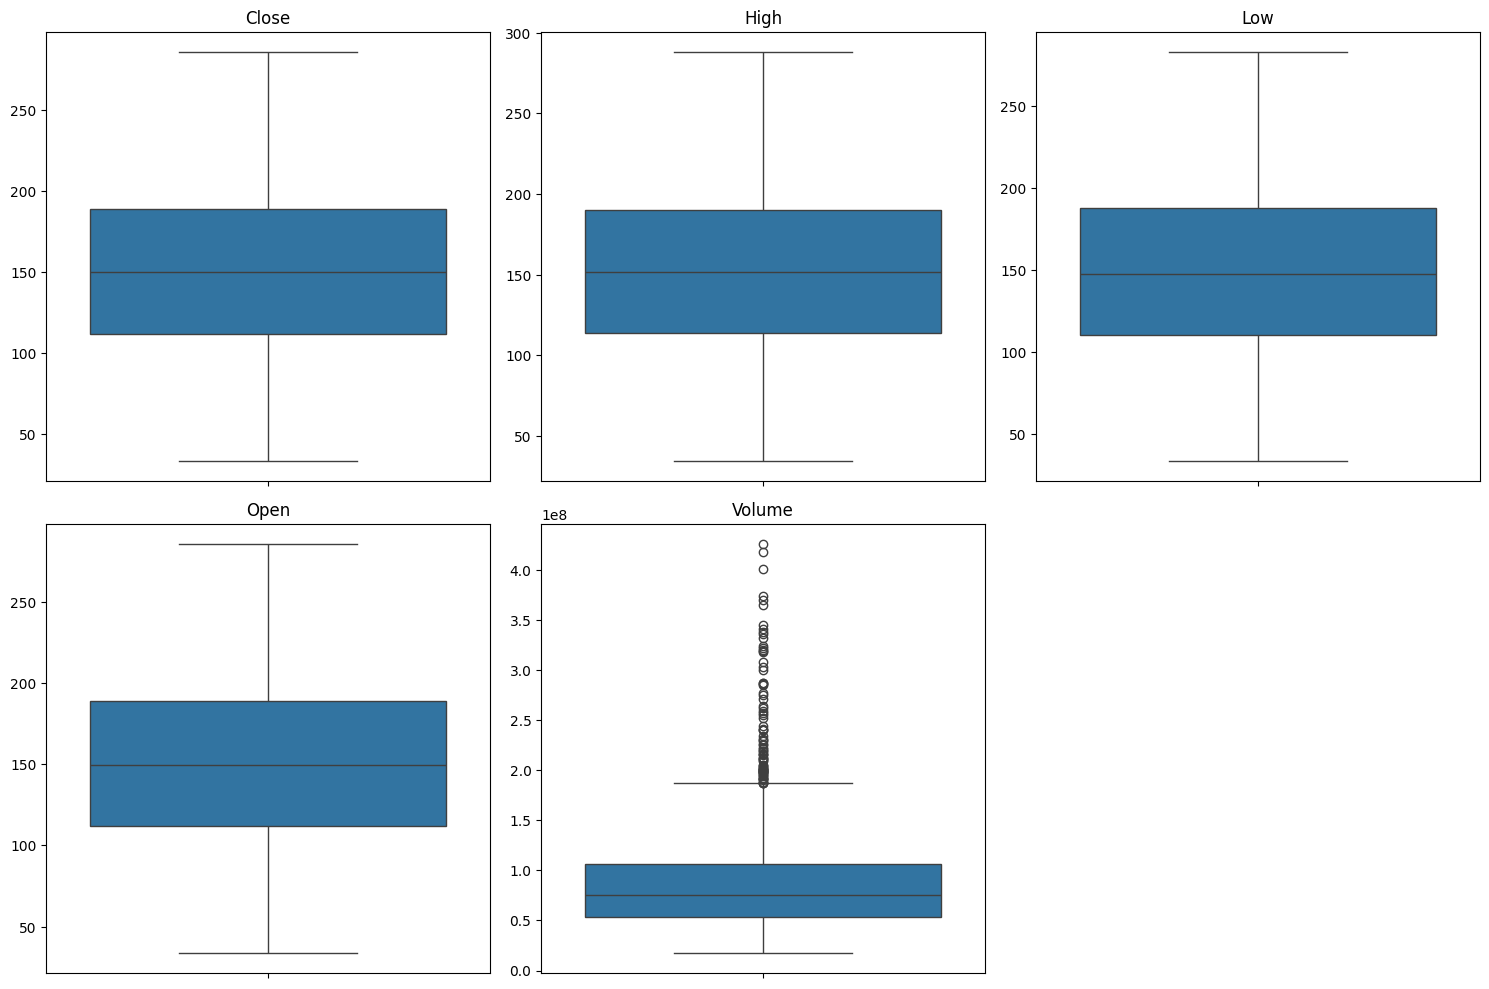

In [13]:
# Check outliers and variations
#import math
#import matplotlib.pyplot as plt
#import seaborn as sns
num_cols = 3
num_features = len(df.columns)
num_rows = math.ceil(num_features / num_cols)

fig = plt.figure(figsize=(15, num_rows * 5))

for i, x in enumerate(df.columns, start=1):
    plt.subplot(num_rows, num_cols, i)
    ax = sns.boxplot(df[x])
    ax.set(xlabel=None)
    plt.title(str(x), loc='center')
    plt.xlabel(None)
    plt.ylabel(None)

plt.tight_layout()
plt.show()

In [14]:
# Data pre-processing
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [15]:
# Handling if missing values
df.bfill()

,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,37.436916,37.657386,36.562155,36.718617,148158800
2019-01-03,33.707920,34.544750,33.662878,34.132260,365248800
2019-01-04,35.146893,35.215643,34.089596,34.262650,234428400
2019-01-07,35.068668,35.282027,34.587432,35.251208,219111200
2019-01-08,35.737183,35.990841,35.208534,35.455078,164101200
...,...,...,...,...,...
2025-12-24,273.066711,274.682309,271.461097,271.600701,17910600
2025-12-26,272.657867,274.622521,272.119325,273.415814,21521800
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200


In [16]:
# Calculate moving averages and daily returns
df['7-day MA'] = df['Close'].rolling(window=7).mean()
df['50-day MA'] = df['Close'].rolling(window=50).mean()
df['Daily Return'] = df['Close'].pct_change()

In [17]:
df[df.isna().values==True].drop_duplicates()

,Close,High,Low,Open,Volume,7-day MA,50-day MA,Daily Return
Date,,,,,,,,
2019-01-02,37.436916,37.657386,36.562155,36.718617,148158800,NaN,NaN,NaN
2019-01-03,33.707920,34.544750,33.662878,34.132260,365248800,NaN,NaN,-0.099607
2019-01-04,35.146893,35.215643,34.089596,34.262650,234428400,NaN,NaN,0.042689
2019-01-07,35.068668,35.282027,34.587432,35.251208,219111200,NaN,NaN,-0.002226
2019-01-08,35.737183,35.990841,35.208534,35.455078,164101200,NaN,NaN,0.019063
2019-01-09,36.344055,36.633272,35.471667,35.865188,180396400,NaN,NaN,0.016982
2019-01-10,36.460220,36.500521,35.763256,36.152038,143122800,35.700265,NaN,0.003196
2019-01-11,36.102261,36.436520,35.917352,36.242130,108092800,35.509600,NaN,-0.009818
2019-01-14,35.559387,35.860458,35.374479,35.760892,129756800,35.774095,NaN,-0.015037


In [18]:
df = df.dropna()   # Drop all NaN
df

,Close,High,Low,Open,Volume,7-day MA,50-day MA,Daily Return
Date,,,,,,,,
2019-03-14,43.742310,43.830401,43.463757,43.782783,94318000,42.350222,39.303858,0.011117
2019-03-15,44.311314,44.599391,43.744687,44.008956,156171600,42.744754,39.441346,0.013008
2019-03-18,44.763672,44.851760,44.232752,44.235136,104879200,43.272611,39.662461,0.010209
2019-03-19,44.408928,44.994605,44.263699,44.842234,126585600,43.735845,39.847702,-0.007925
2019-03-20,44.797001,45.113647,43.980387,44.337506,124140800,44.050791,40.042269,0.008739
...,...,...,...,...,...,...,...,...
2025-12-24,273.066711,274.682309,271.461097,271.600701,17910600,272.038095,270.219035,0.005324
2025-12-26,272.657867,274.622521,272.119325,273.415814,21521800,271.865714,270.703746,-0.001497
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200,272.139260,271.233298,0.001317


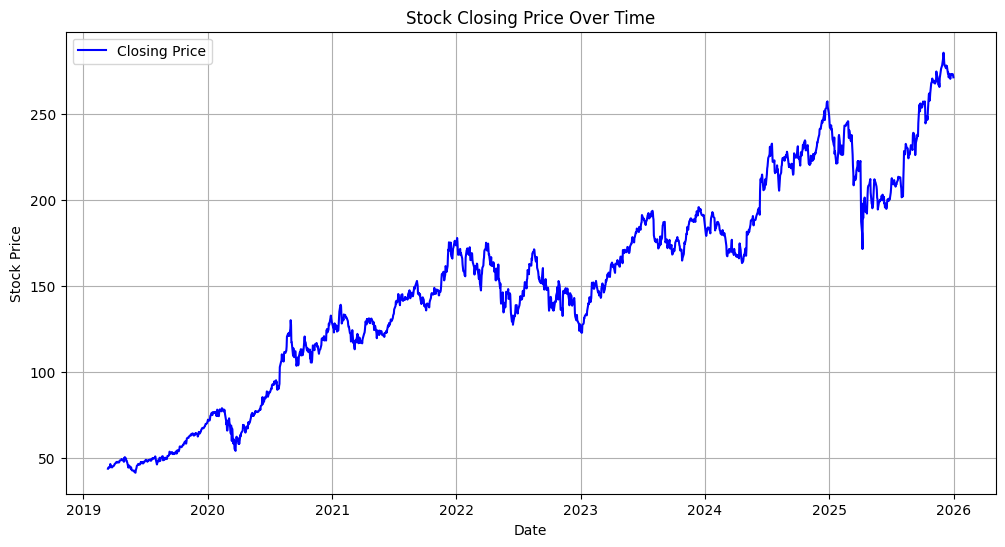

In [19]:
# EDA - explore trends and patterns
plt.figure(figsize=(12,6))
plt.xlabel("Date")  
plt.ylabel("Stock Price")  
plt.title("Stock Closing Price Over Time")  
plt.plot(df['Close'], label="Closing Price", color="blue")
#plt.plot(df['Date'], df['Close'], label="Closing Price", color="blue")  
plt.grid(True)
plt.legend()  
plt.show()

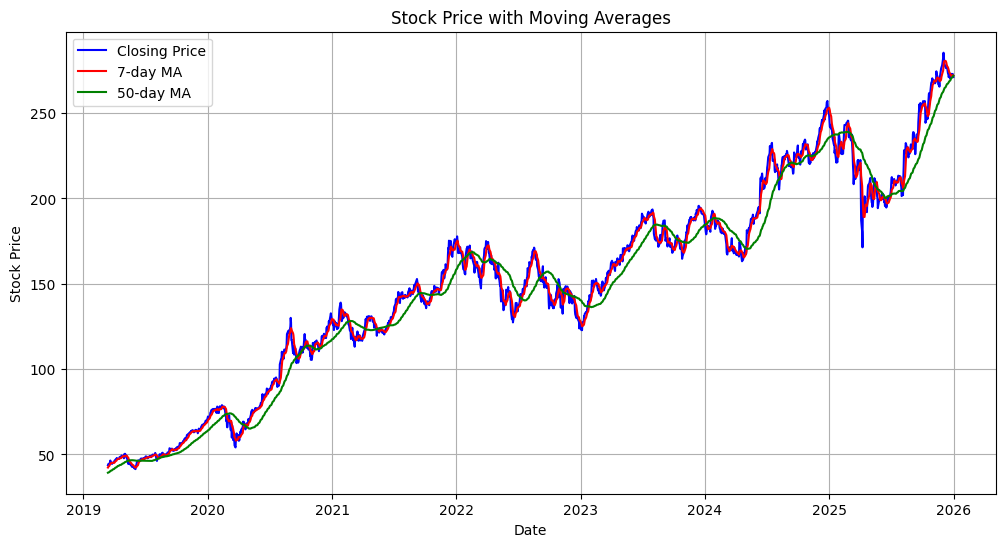

In [20]:
# Smoothen short-term fluctuations with moving averages
plt.figure(figsize=(12,6))
plt.xlabel("Date")  
plt.ylabel("Stock Price")  
plt.title("Stock Price with Moving Averages")
plt.plot(df['Close'], label="Closing Price", color="blue")
plt.plot(df['7-day MA'], label="7-day MA", color="red")
plt.plot(df['50-day MA'], label="50-day MA", color="green")
#plt.plot(df['Date'], df['Close'], label="Closing Price", color="blue")  
plt.grid(True)
plt.legend()  
plt.show()


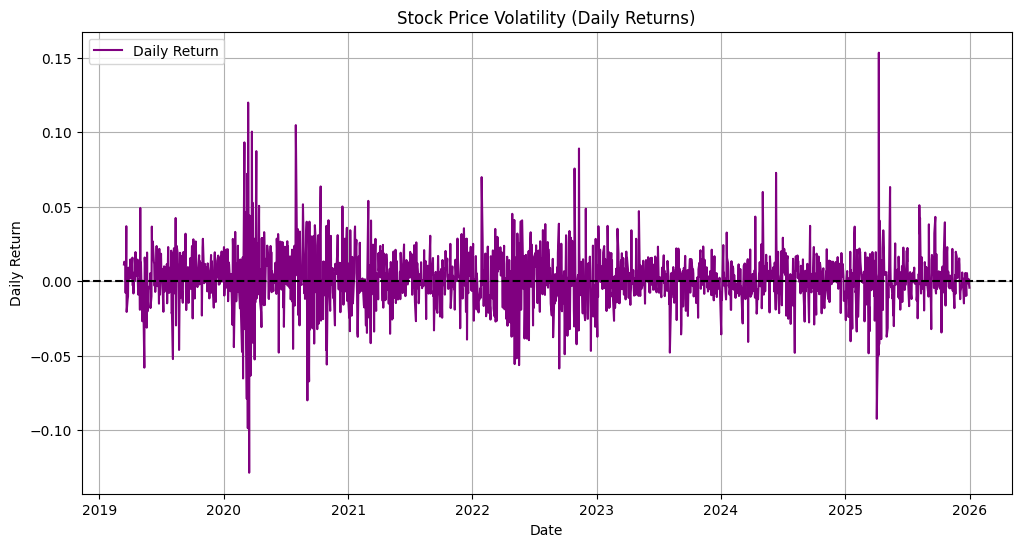

In [21]:
# Analyse Volatility
plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.title("Stock Price Volatility (Daily Returns)")
plt.plot(df['Daily Return'], label="Daily Return", color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

In [22]:
# Normailized Data
# from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))  
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1,1))

In [23]:
# ADF Test : p-value < 0.05 for stationary data
#from statsmodels.tsa.stattools import adfuller

close_series = df['Close']
def check_stationarity(series):
    result = adfuller(series.dropna())  # Drop NaN values if any
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

check_stationarity(close_series)

ADF Statistic: -0.7784766165550603
p-value: 0.8253627917988784
The series is not stationary.


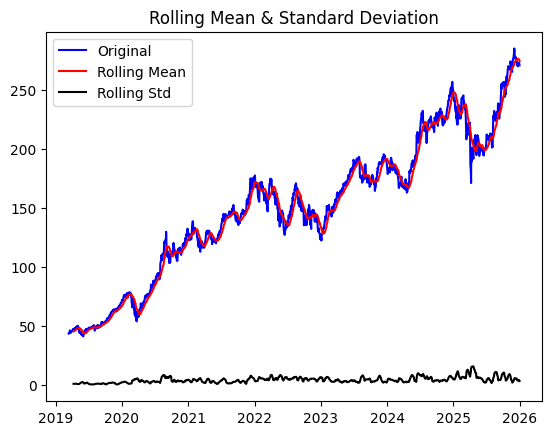

Results of Dickey-Fuller Test:
Test Statistic                   -0.778477
p-value                           0.825363
#Lags Used                        0.000000
Number of Observations Used    1710.000000
Critical Value (1%)              -3.434180
Critical Value (5%)              -2.863232
Critical Value (10%)             -2.567671
dtype: float64


In [24]:
#...3 Multiple-Step LSTM

close_series = df['Close']
def test_stationarity(timeseries):
    '''
    Input: timeseries (dataframe): timeseries for which we want to study the stationarity
    '''
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(20).mean()
    rolstd = timeseries.rolling(20).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value',\
                                             '#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

test_stationarity(close_series)

<Figure size 640x480 with 0 Axes>

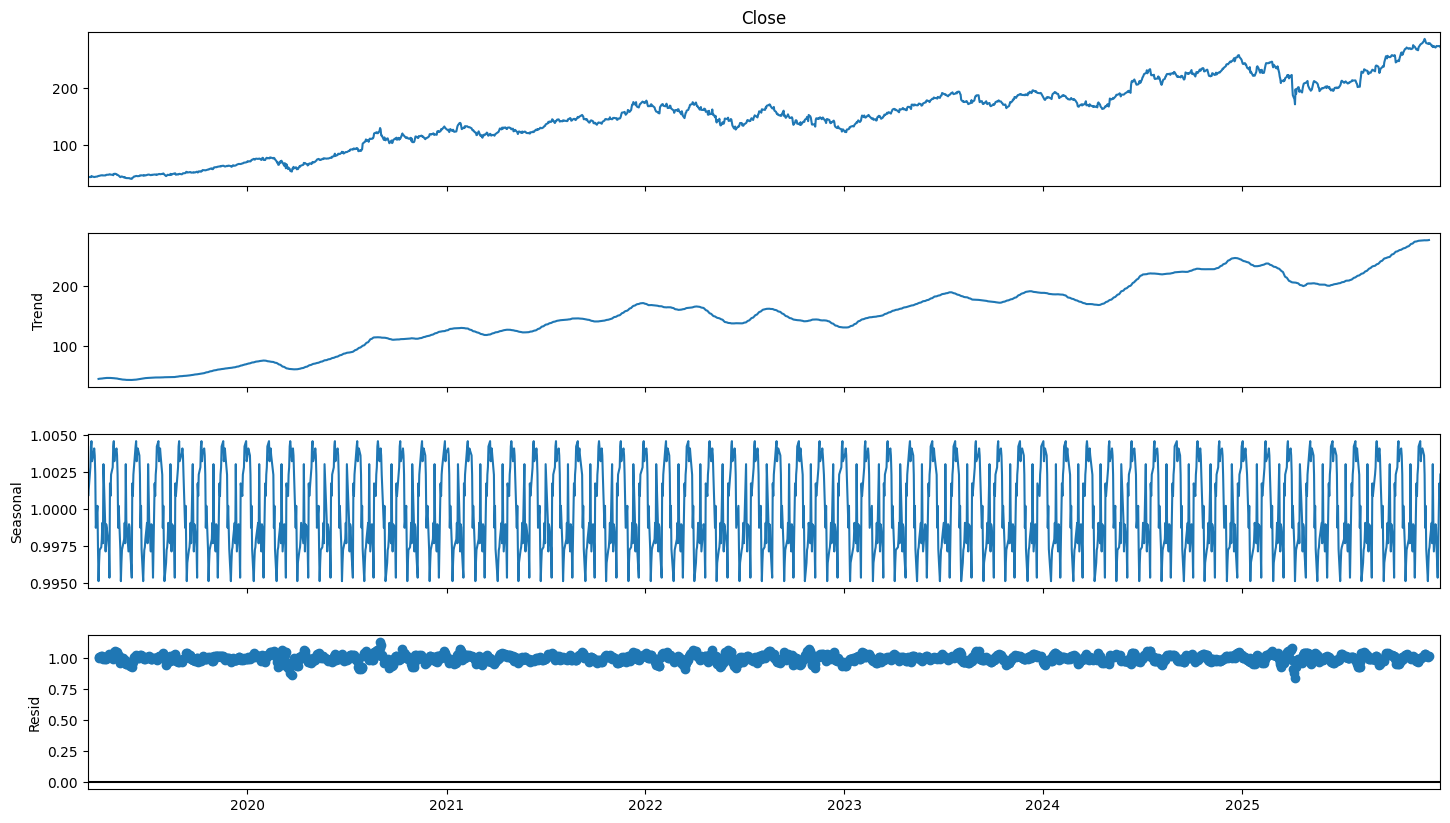

In [26]:
#...
#from statsmodels.tsa.seasonal import seasonal_decompose

#To plot the trend and the seasonality
# set the period to 28

df_close = df['Close']
result = seasonal_decompose(df_close, model='multiplicative',period=28)
fig = plt.figure()  
fig = result.plot()  
fig.set_size_inches(16, 9)

Text(0.5, 1.0, 'Transformed data')

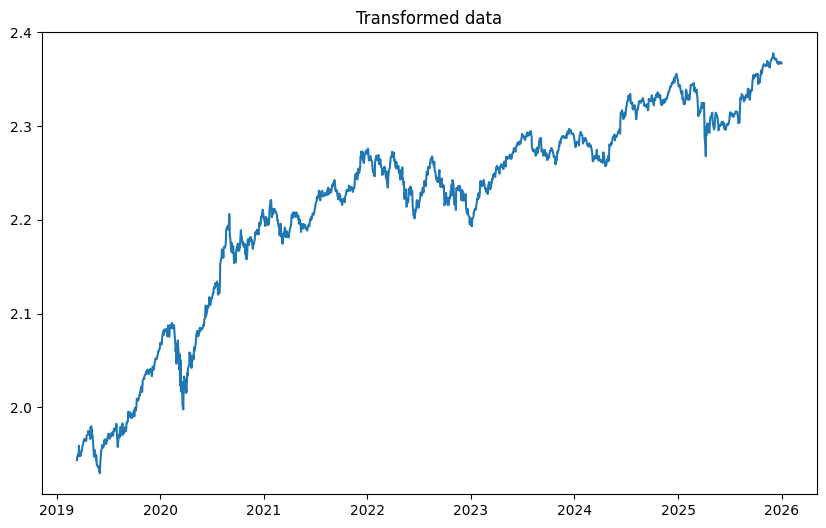

In [27]:
#... To apply log transform to reduce the trends effect while square root transform to flatten 

df_close_log = df_close.apply(np.log)
df_close_tf = df_close_log.apply(np.sqrt)

plt.figure(figsize = (10,6))
plt.plot(df_close_tf)
plt.title('Transformed data')

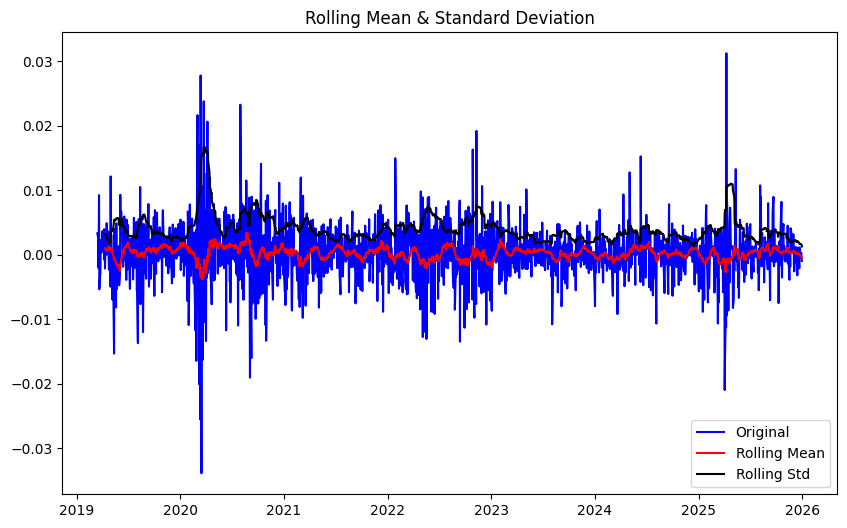

Results of Dickey-Fuller Test:
Test Statistic                -1.324008e+01
p-value                        9.208962e-25
#Lags Used                     9.000000e+00
Number of Observations Used    1.700000e+03
Critical Value (1%)           -3.434202e+00
Critical Value (5%)           -2.863242e+00
Critical Value (10%)          -2.567676e+00
dtype: float64


In [28]:
#... classical methold differenciating to handel with trand and seasonality
df_close_shift = df_close_tf - df_close_tf.shift()

df_close_shift.dropna(inplace=True)
plt.figure(figsize = (10,6))
test_stationarity(df_close_shift)

In [29]:
#...MS LSTM
def preprocess_lstm(sequence, n_steps,n_features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the sequence
        if end_ix >= len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
        
    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    return X, y

In [30]:
#...
# choose the number of days on which to base our predictions 
nb_days = 60

n_features = 1

X, y = preprocess_lstm(df_close_shift.to_numpy(), nb_days, n_features)

In [31]:
#...
#Split the data set between the training set and the test set
test_days = 365 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

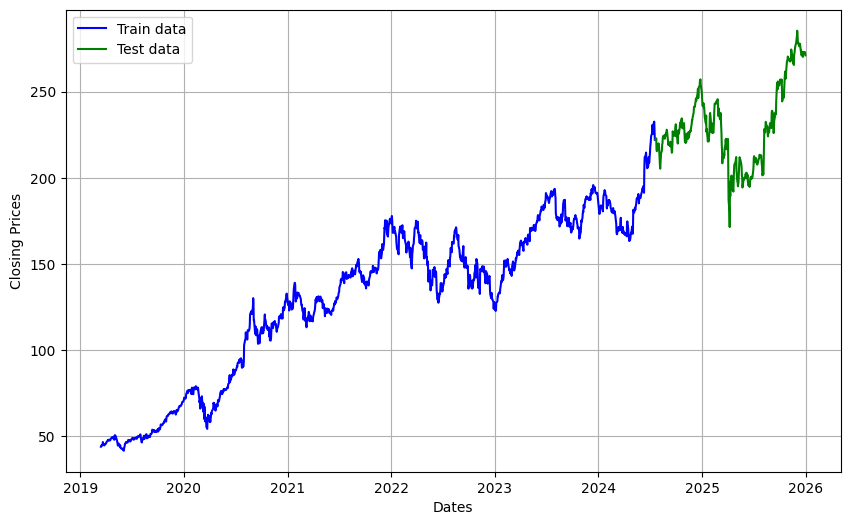

In [32]:
#... Split Data
train_original = df_close.iloc[:-test_days]
test_original = df_close.iloc[-test_days:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.legend()

In [33]:
#... LSTM Vanilla LSTM
def vanilla_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(1))
    return model

In [34]:
#...
model = vanilla_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
#...Train and evaluate model
model.fit(X_train, 
          y_train, 
          epochs=15, 
          batch_size = 32)

Epoch 1/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 3.0019e-05 - mean_absolute_error: 0.0041
Epoch 2/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.2028e-05 - mean_absolute_error: 0.0033
Epoch 3/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.2440e-05 - mean_absolute_error: 0.0034
Epoch 4/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.2343e-05 - mean_absolute_error: 0.0034
Epoch 5/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.1891e-05 - mean_absolute_error: 0.0033
Epoch 6/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.1722e-05 - mean_absolute_error: 0.0033
Epoch 7/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.3319e-05 - mean_absolute_error: 0.0035
Epoch 8/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.3200e-05 - mean_absolute_error: 0.0034
Epoch 9/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.2193e-05 - mean_absolute_error: 0.0034
Epoch 10/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.1983e-05 - mean_absolute_error: 0.0033

In [36]:
#...
# Evaluate the model on the test data using
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)
print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.5962e-05 - mean_absolute_error: 0.0025
Test MSE: 1.5962148609105498e-05
Test MAE: 0.0025426913052797318


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


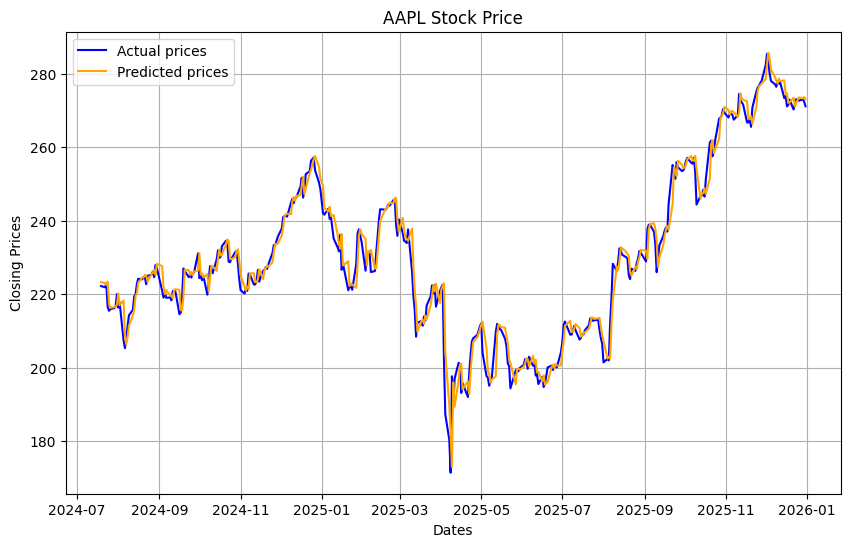

In [37]:
#...
# Prediction
y_pred = model.predict(X_test)

# We create a dataframe from y_pred to have date-time indexes.
pred_data = pd.DataFrame(y_pred[:,0], test_original.index,columns=['Close'])

# Apply inverse transformation from 1.d

# Add the differenciation term
pred_data['Close'] = pred_data['Close'] + df_close_tf.shift().values[-test_days:] 

# Take the square, and the exponent
pred_data = pred_data.apply(np.square)
pred_data = pred_data.apply(np.exp)

# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original,'b',label='Actual prices')
plt.plot(pred_data, 'orange',label='Predicted prices')
#plt.title(' Stock Price')
plt.title(company + ' Stock Price')

plt.legend()

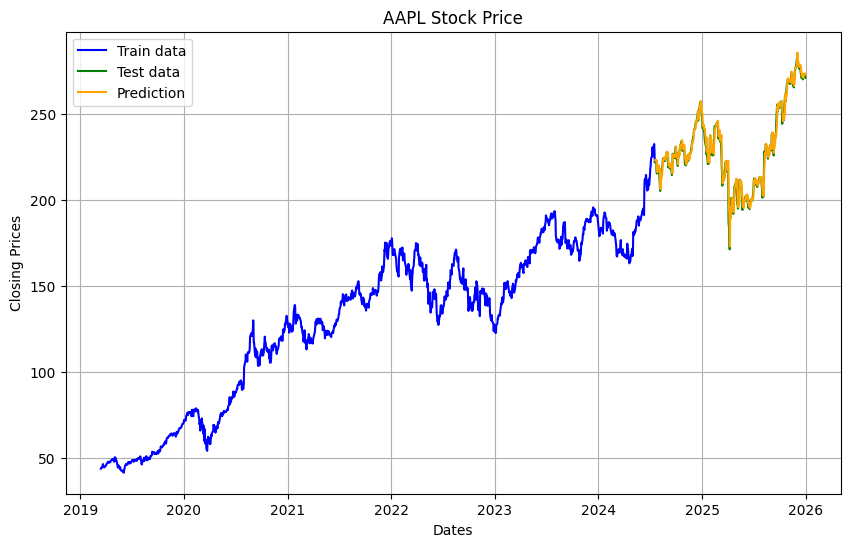

In [38]:
#...
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.plot(pred_data, 'orange', label='Prediction')
plt.title(company + ' Stock Price')
plt.legend()

In [39]:
#...Multiple-Step LSTM
def preprocess_multistep_lstm(sequence, n_steps_in, n_steps_out, features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the sequence
        if out_end_ix > len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)

    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    
    return X, y

In [40]:
#...
# Number of days into the future we want to predict
n_steps_out = 10

# choose the number of days on which to base our predictions 
nb_days = 60

n_features = 1

X, y = preprocess_multistep_lstm(df_close_shift.to_numpy(), nb_days, n_steps_out, n_features)

In [41]:
#...
#Split the data set between the training set and the test set
test_days = 365 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

In [42]:
#...
def vanilla_multistep_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(n_steps_out))
    return model


In [43]:
#...
model = vanilla_multistep_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,910 (42.62 KB)

 Trainable params: 10,910 (42.62 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
#...
model.fit(X_train, 
          y_train, 
          epochs=15, 
          batch_size = 32)

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 2.2686e-05 - mean_absolute_error: 0.0034
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.2454e-05 - mean_absolute_error: 0.0034
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.2897e-05 - mean_absolute_error: 0.0034
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.2594e-05 - mean_absolute_error: 0.0034
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.2180e-05 - mean_absolute_error: 0.0033
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.2337e-05 - mean_absolute_error: 0.0033
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.2103e-05 - mean_absolute_error: 0.0033
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.2074e-05 - mean_absolute_error: 0.0033
Epoch 9/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.2294e-05 - mean_absolute_error: 0.0033
Epoch 10/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.2026e-05 - mean_absolute_error: 0.0033

In [45]:
#...
# Evaluate the model on the test set
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)

print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.6258e-05 - mean_absolute_error: 0.0026
Test MSE: 1.6257979950751178e-05
Test MAE: 0.0026235259138047695


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


Text(0.5, 1.0, 'Original data vs predictions in the transformed space')

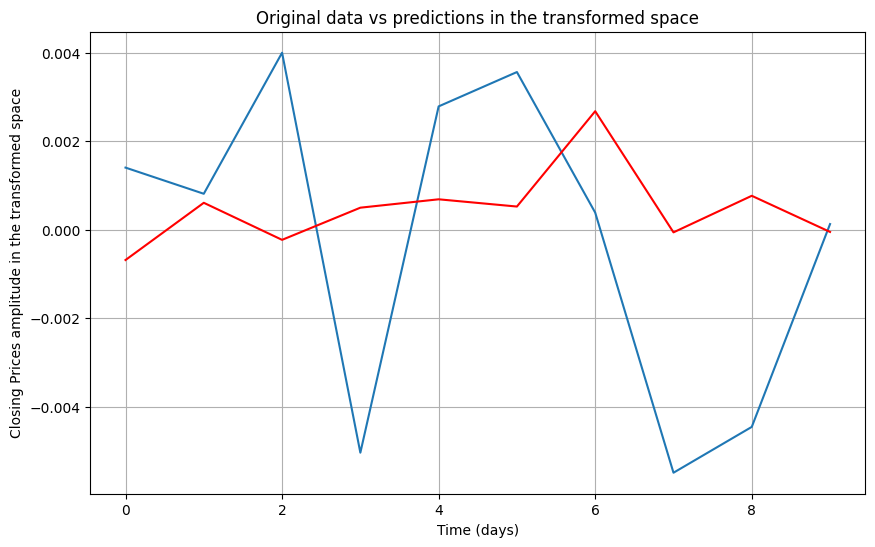

In [46]:
#...
# Prediction
y_pred = model.predict(X_test)

# the_day is the day from which we will study the n_steps_out-th dayS of prediction into 
# the future. Note: The first day start at index 0
the_day = 0
y_pred_days = y_pred[the_day,:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.plot(y_test[the_day,:],label='Orginal data - transformed')
plt.plot(y_pred_days, color='red',label='Predictions - transformed')
plt.xlabel('Time (days)')
plt.ylabel('Closing Prices amplitude in the transformed space')
plt.title('Original data vs predictions in the transformed space')

In [47]:
#...
# Apply inverse transformations from 3.a

# Add the differenciation term
pred_diff_cumsum = y_pred_days.cumsum()

base_number = df_close_tf.values[-test_days+the_day+nb_days-1]
idx = test_original.iloc[the_day:the_day+n_steps_out].index

pred_tf = pd.Series(base_number, index=idx)
pred_tf = pred_tf.add(pred_diff_cumsum,fill_value=0)

print(pred_tf)

Date
2024-07-19    2.327195
2024-07-22    2.327800
2024-07-23    2.327568
2024-07-24    2.328063
2024-07-25    2.328747
2024-07-26    2.329268
2024-07-29    2.331943
2024-07-30    2.331880
2024-07-31    2.332644
2024-08-01    2.332590
dtype: float64


In [48]:
#...
# Take the square, and the exponent
pred_log = pred_tf.apply(np.square)
pred = pred_log.apply(np.exp)
print(pred)

Date
2024-07-19    224.940676
2024-07-22    225.575365
2024-07-23    225.331792
2024-07-24    225.851573
2024-07-25    226.572260
2024-07-26    227.122229
2024-07-29    229.971677
2024-07-30    229.904517
2024-07-31    230.724813
2024-08-01    230.667646
dtype: float64


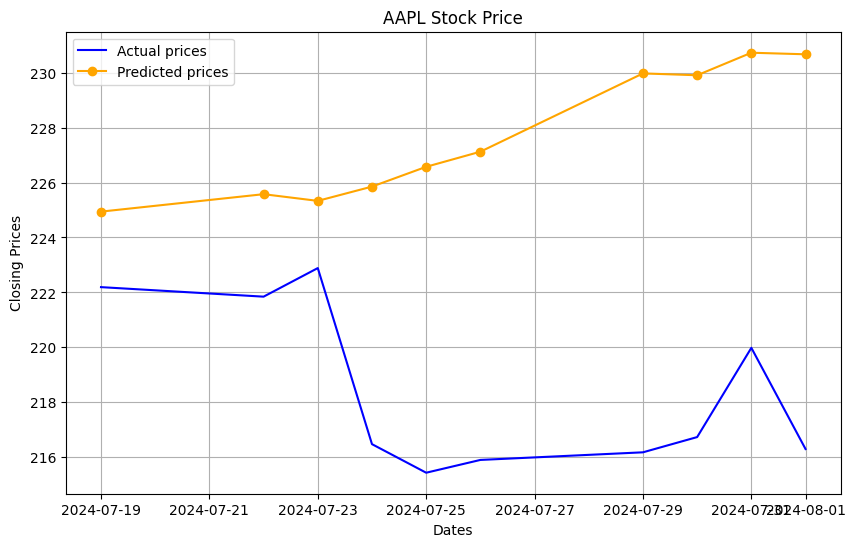

In [49]:
#...
# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original.iloc[max(0,the_day-30):the_day+n_steps_out],'b',label='Actual prices')
plt.plot(pred, '-o',color='orange',label='Predicted prices')
plt.title(company + ' Stock Price')

plt.legend()

In [50]:
#
scaler = MinMaxScaler()
df['Close'] = scaler.fit_transform(df[['Close']])

In [51]:
# Train and Verify Split (80:20 Ratio)
#from sklearn.model_selection import train_test_split

def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back)])
        dataY.append(dataset[i + look_back])
    return np.array(dataX), np.array(dataY)

close_values = df['Close'].values 

X, Y = create_dataset(close_values, look_back=30)

trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, shuffle=False)


In [52]:
# Data for LSTM 
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

In [110]:
#1 LSTM
model = Sequential()
model.add(LSTM(units=50, input_shape=(30, 1)))
model.add(Dense(units=1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()
model.fit(trainX, trainY, epochs=30, batch_size=32)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0250
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0025
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0013
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0012
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0012
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0012
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0011
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0011
Epoch 9/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0010
Epoch 10/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0011
Epoch 11/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 9.4472e-04
Epoch 12/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 9.2261e-04
Epoch 13/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 9.4132e-04
Epoch 14/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 8.5659e-04
Epoch 15/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - l

In [53]:
#2 LSTM
#from tensorflow.keras.models import Sequential  
#from tensorflow.keras.layers import LSTM, Dense, Dropout  

model = Sequential([  
    LSTM(units=50, return_sequences=True, input_shape=(trainX.shape[1], 1)),  
    Dropout(0.2),  
    LSTM(units=50, return_sequences=False),  
    Dropout(0.2),  
    Dense(units=25),  
    Dense(units=1)  
])  

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(trainX, trainY, epochs=30, batch_size=32)

Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0163
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0023
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0020
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0019
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0017
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0015
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0013
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0013
Epoch 9/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012
Epoch 10/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012
Epoch 11/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0010
Epoch 12/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0010    
Epoch 13/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.9985e-04
Epoch 14/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.3549e-04
Epoch 15/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss:

In [54]:
# Prediction & Result
testPredict = model.predict(testX)
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform(testY.reshape(-1, 1))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [55]:
#from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(testY, testPredict))
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 8.953058641376819


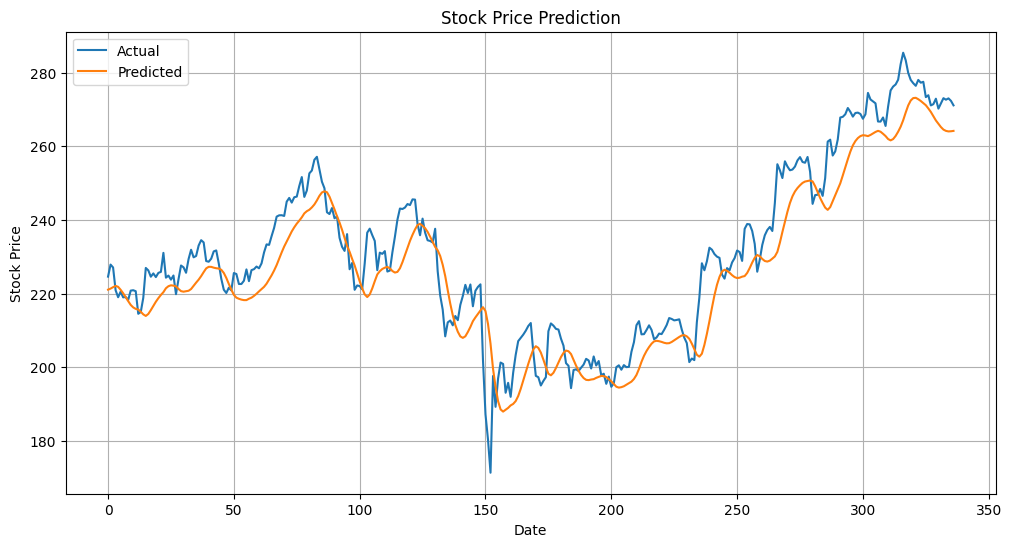

In [56]:
#1
plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Stock Price Prediction")
plt.plot(testY, label='Actual')
plt.plot(testPredict, label='Predicted')
plt.grid(True)
plt.legend()
plt.show()

For this study, we will focus on the closing price, as it represents the final market sentiment for each trading day.